In [1]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 1, header = 1)
df.head()

,Run,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,49.646944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001_MCALR N-PROD 2000L_1003145,49.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN
2,FA001_MCALR N-PROD 2000L_1003145,49.746667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.047,NaN,NaN,NaN,-0.067209,NaN,NaN,NaN
3,FA001_MCALR N-PROD 2000L_1003145,49.750556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.0,NaN,NaN,NaN,NaN
4,FA001_MCALR N-PROD 2000L_1003145,49.751944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.1,NaN,NaN


In [3]:
first_df = pd.read_excel("./data/mCALR-N step data-17mar2026.xlsx", sheet_name = 0, header = 1)
first_df = first_df.loc[2:].reset_index(drop = True)
first_df.head()

,Unnamed: 0,Variable,CNT_CAT_VAR_MES,CNT_SCALAR_MES,CNT_TIME_DATA_MES,CNT_TIME_VAR_MES,Generic.Bioreactor.End Culture.Bolus antifoam.Total Qty,Generic.Bioreactor.End Culture.Bolus base.Total Qty,Generic.Bioreactor.End Culture.Cell age at harvest,Generic.Bioreactor.End Culture.Culture duration,...,STR2K_D14_4_1_PA_HPLC_Concentration,1M Sodium Carbonate Solution,CAMPAIGN,Cell Boost 7a feed medium,Cell Boost 7b feed medium,Glucose 500 g/L,Location,MO_BR_REP_STATUS,OPTICHO GROWTH MEDIUM,SKU
0,FA001,FA001_MCALR N-PROD 2000L_1003145,9,25,318,21,2.462,21.128,36,331,...,5.19,1003086.0,FA001,1003097.0,1003096.0,1003060.0,YVE Bioplant,NaN,1003078.0,20001496.0
1,FA002,FA002_MCALR N-PROD 2000L_1003309,9,25,315,21,1.561,21.957,36,331,...,4.86,1003086.0,FA002,1003269.0,1003268.0,1003060.0,YVE Bioplant,NaN,1003211.0,20001496.0
2,FA003,FA003_MCALR N-PROD 2000L_1003389,9,25,315,21,1.38,22.126,36,332,...,4.63,1003086.0,FA003,1003364.0,1003365.0,1003060.0,YVE Bioplant,NaN,1003311.0,20001496.0
3,FA004,FA004_MCALR N-PROD 2000L_1004167,9,25,313,21,1.754,-1.295,36,333,...,4.62,1004000.0,FA004,1004094.0,1004095.0,1004093.0,YVE Bioplant,NaN,1004092.0,20001496.0
4,FA005,FA005_MCALR N-PROD 2000L_1004168,10,25,311,21,1.78,0.15,36,334,...,3.91,1004000.0,FA005,1004165.0,1004095.0,1004093.0,YVE Bioplant,NaN,1004150.0,20001496.0


In [4]:
labels = first_df[first_df.columns[[0, -10]]]
labels.head()

,Unnamed: 0,STR2K_D14_4_1_PA_HPLC_Concentration
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91


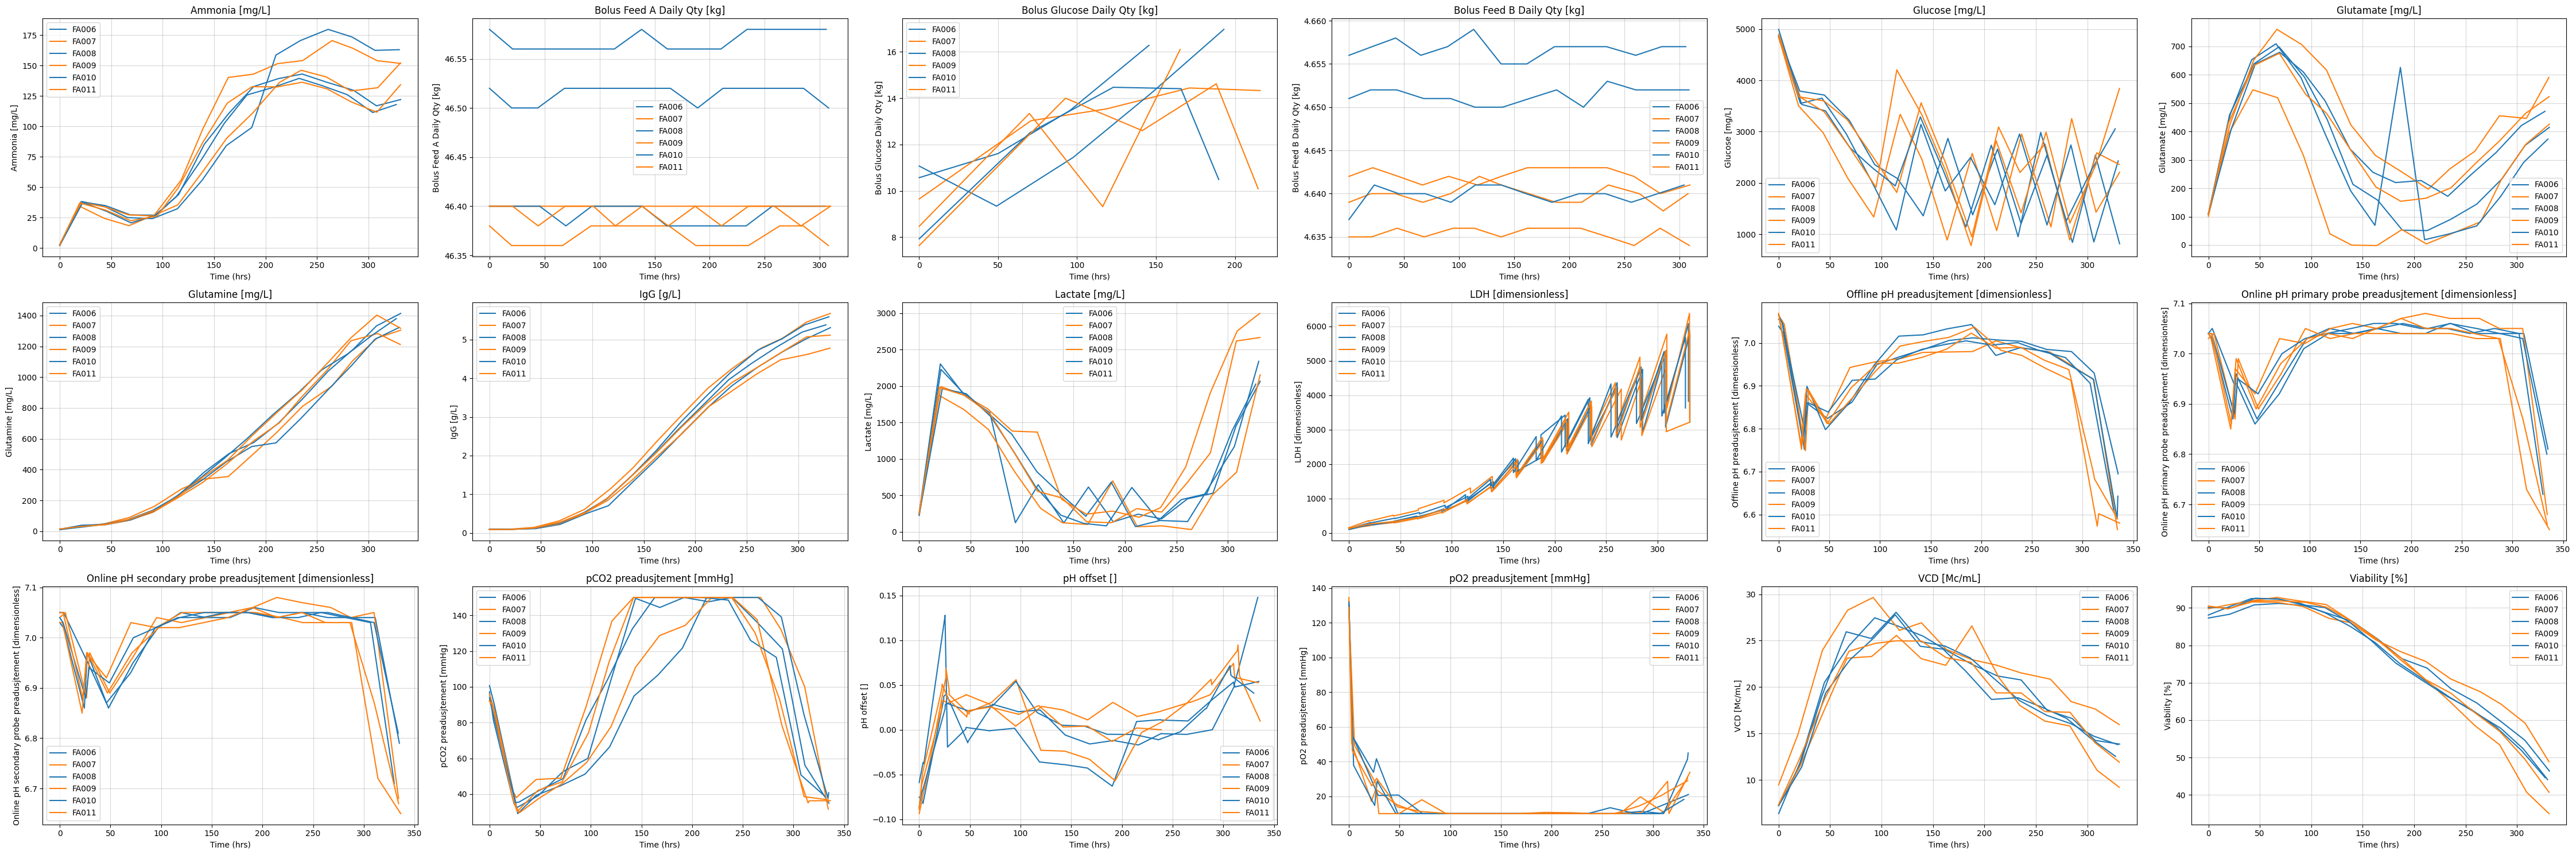

In [5]:
fig, axs = plt.subplots(3, 6, figsize = (45, 15))

uniq_runs = sorted(df["Run"].unique())

colors = [
    "blue",
    "blue",
    "red",
    "red",
    "red",
    "green",
    "green",
    "green",
    "red",
    "green",
    "blue"
]

# limited_df = 

colors = ["C0", "C1", "C0", "C1", "C0", "C1"]
for run_idx, run in enumerate(uniq_runs[5:]):
    for idx, col in enumerate(df.columns[2:]):
        row_idx = idx // 6
        col_idx = idx % 6

        ax = axs[row_idx][col_idx]
        
        sub_df = df[df["Run"] == run][["Process Time [h]", col]].copy()
        # sub_df = sub_df[sub_df["Process Time [h]"] < (24 * 4) + 10 + sub_df["Process Time [h]"].min()]
        sub_df = sub_df[~sub_df[col].isna()]
        ax.plot(sub_df["Process Time [h]"] - sub_df["Process Time [h]"].min(), sub_df[col], label = run.split("_")[0], c = colors[run_idx])
        # ax.plot(sub_df["Process Time [h]"] - sub_df["Process Time [h]"].min(), sub_df[col])
        
        if run_idx == 5:
            # ax.vlines(24 * 3, df[col].min(), df[col].max(), linestyle = '--', color = "C0")
            ax.set_title(col)
            ax.set_xlabel("Time (hrs)")
            ax.set_ylabel(col)
            ax.legend()
            ax.grid(alpha = 0.5)

        

fig.tight_layout()
fig.savefig("./test.png")

In [6]:
labels.tail(6)

,Unnamed: 0,STR2K_D14_4_1_PA_HPLC_Concentration
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56
10,FA011,5.08


In [7]:
df.head(2)

,Run,Process Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,49.646944,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001_MCALR N-PROD 2000L_1003145,49.650000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN


In [8]:
start_df = df[["Run", "Process Time [h]"]].sort_values(by = ["Run", "Process Time [h]"]).drop_duplicates("Run", keep = "first")
start_df.columns = ["Run", "Start Time [h]"]
merged_df = pd.merge(start_df, df, on = "Run")
merged_df.insert(3, "Run Time [h]", merged_df["Process Time [h]"] - merged_df["Start Time [h]"])
merged_df.head(3)

,Run,Start Time [h],Process Time [h],Run Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],...,Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.646944,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.650000,0.003056,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN
2,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.746667,0.099722,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.047,NaN,NaN,NaN,-0.067209,NaN,NaN,NaN


In [9]:
four_month = merged_df[merged_df["Run Time [h]"] < 24 * 4][["Run"] + merged_df.columns[4:].tolist()].groupby("Run").mean().reset_index()
four_month.insert(1, "Batch", four_month["Run"].apply(lambda x: x.split("_")[0]))
four_month

,Run,Batch,Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,FA001,19.19900,40.970,NaN,4.09800,3254.2500,384.1950,38.2250,0.14475,1434.2350,442.2875,6.916333,6.981667,6.985000,59.600000,0.012099,46.133333,15.2150,89.900
1,FA002_MCALR N-PROD 2000L_1003309,FA002,20.52875,40.995,NaN,4.09825,3144.0650,387.6375,38.8625,0.14475,1316.3700,261.3625,6.909167,6.970000,6.980000,62.966667,0.005531,43.200000,16.1700,90.850
2,FA003_MCALR N-PROD 2000L_1003389,FA003,20.21500,40.925,NaN,4.08350,3417.6800,386.0475,43.1875,0.13600,1394.5475,232.3750,6.920714,6.995714,6.992857,63.757143,0.021319,39.842857,17.3020,90.400
3,FA004_MCALR N-PROD 2000L_1004167,FA004,26.17150,46.330,NaN,4.63375,3951.1600,480.8650,37.0175,0.22450,1415.3225,234.1000,6.911286,6.964286,6.955714,61.214286,-0.002322,35.400000,17.7620,90.980
4,FA005_MCALR N-PROD 2000L_1004168,FA005,24.61700,46.490,NaN,4.64475,3860.0700,480.6375,37.9375,0.13575,1498.6275,219.4500,6.918143,6.972857,6.971429,56.614286,0.001413,37.000000,16.9525,92.300
5,FA006_MCALR N-PROD 2000L_1004480,FA006,25.82025,46.510,NaN,4.65150,3899.0250,475.9225,41.2350,0.13350,1514.4325,358.0500,6.904667,6.953333,6.948333,56.283333,-0.005386,46.983333,15.7800,89.400
6,FA007_MCALR N-PROD 2000L_1004483,FA007,21.44900,46.365,NaN,4.63950,2950.3520,374.4840,68.1380,0.25120,1210.7960,523.4500,6.923143,6.980000,6.978571,63.814286,0.003625,37.400000,21.2540,90.760
7,FA008_MCALR N-PROD 2000L_1004510,FA008,25.08060,46.564,NaN,4.65675,3411.8200,504.5320,61.0840,0.20680,1469.6660,362.8800,6.903286,6.965714,6.975714,56.000000,0.006959,34.728571,17.8060,90.940
8,FA009_MCALR N-PROD 2000L_1004561,FA009,25.44425,46.400,NaN,4.64200,3852.5650,486.6125,38.6375,0.13400,1445.1400,266.7250,6.904667,6.975714,6.975714,54.633333,0.011993,40.166667,14.8225,91.375
9,FA010_MCALR N-PROD 2000L_1004602,FA010,23.50560,46.395,NaN,4.63950,3378.5680,489.6720,59.2480,0.22380,1354.2260,370.5000,6.919571,6.980000,6.974286,60.414286,0.007103,38.757143,17.2280,91.160


In [10]:
four_month[col]

0     89.900
1     90.850
2     90.400
3     90.980
4     92.300
5     89.400
6     90.760
7     90.940
8     91.375
9     91.160
10    91.000
Name: Viability [%], dtype: float64

In [11]:
np.corrcoef(four_month[col].tolist(), labels[labels.columns[-1]].tolist())

array([[ 1.       , -0.5335537],
       [-0.5335537,  1.       ]])

In [12]:
corr_df = []
for col in four_month.columns[2:]:
    corr = np.corrcoef(four_month[col].tolist(), labels[labels.columns[-1]].tolist())[0, 1]
    corr_df.append([col, corr, abs(corr)])

pd.DataFrame(corr_df, columns = ["Feature", "Correlation", "Abs Correlation"]).sort_values(by = "Abs Correlation", ascending = False)

,Feature,Correlation,Abs Correlation
9,LDH [dimensionless],0.791614,0.791614
6,Glutamine [mg/L],0.731530,0.731530
17,Viability [%],-0.533554,0.533554
7,IgG [g/L],0.497121,0.497121
4,Glucose [mg/L],-0.456588,0.456588
16,VCD [Mc/mL],0.299953,0.299953
8,Lactate [mg/L],-0.279870,0.279870
3,Bolus Feed B Daily Qty [kg],0.223294,0.223294
1,Bolus Feed A Daily Qty [kg],0.217033,0.217033
11,Online pH primary probe preadusjtement [dimens...,-0.200661,0.200661


In [13]:
merged_df[merged_df["Run Time [h]"] < 24 * 4]

,Run,Start Time [h],Process Time [h],Run Time [h],Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],...,Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.646944,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,7.04,NaN,NaN,NaN,NaN,NaN,NaN
1,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.650000,0.003056,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.05,NaN,NaN,NaN,NaN,NaN
2,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.746667,0.099722,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,7.047,NaN,NaN,NaN,-0.067209,NaN,NaN,NaN
3,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.750556,0.103611,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,101.0,NaN,NaN,NaN,NaN
4,FA001_MCALR N-PROD 2000L_1003145,49.646944,49.751944,0.105000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,136.1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3096,FA011_MCALR N-PROD 2000L_1004660,42.648056,115.488333,72.840278,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3097,FA011_MCALR N-PROD 2000L_1004660,42.648056,116.376389,73.728333,NaN,46.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3098,FA011_MCALR N-PROD 2000L_1004660,42.648056,116.376667,73.728611,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3099,FA011_MCALR N-PROD 2000L_1004660,42.648056,117.417222,74.769167,NaN,NaN,NaN,4.635,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


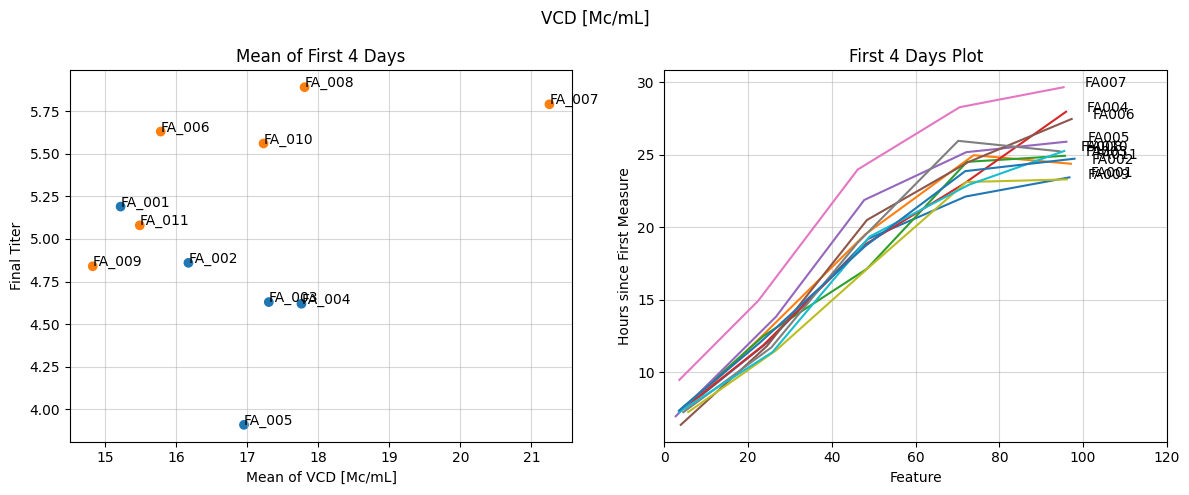

In [14]:
feature = "VCD [Mc/mL]"

fig, axs = plt.subplots(1, 2, figsize = (12, 5))

ax = axs[0]
colors = ["C0"] * 5 + ["C1"] * 6
ax.scatter(four_month[feature], labels[labels.columns[-1]], c = colors)
for idx, (i, j) in enumerate(zip(four_month[feature], labels[labels.columns[-1]])):
    ax.text(i, j, f"FA_{str(idx + 1).zfill(3)}")
ax.grid(alpha = 0.5)
ax.set_title("Mean of First 4 Days")
ax.set_ylabel("Final Titer")
ax.set_xlabel(f"Mean of {feature}")

ax = axs[1]
for run_idx, run in enumerate(sorted(merged_df["Run"].unique())):
    sub_df = merged_df[merged_df["Run"] == run]
    sub_df = sub_df[sub_df["Run Time [h]"] < (100)]
    sub_df = sub_df[~sub_df[feature].isna()]
    ax.plot(sub_df["Run Time [h]"], sub_df[feature])
    ax.text(sub_df["Run Time [h]"].max() + 5, sub_df[feature].iloc[-1], run.split("_")[0])
ax.set_xlim(0, 120)
ax.grid(alpha = 0.5)
ax.set_title("First 4 Days Plot")
ax.set_ylabel("Hours since First Measure")
ax.set_xlabel("Feature")

fig.suptitle(feature)
fig.tight_layout()

In [21]:
labels

,Unnamed: 0,STR2K_D14_4_1_PA_HPLC_Concentration
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56


glutamate
glucose
offline ph
ldh
lactate
pCO2
ammonia

In [20]:
four_month

,Run,Batch,Ammonia [mg/L],Bolus Feed A Daily Qty [kg],Bolus Glucose Daily Qty [kg],Bolus Feed B Daily Qty [kg],Glucose [mg/L],Glutamate [mg/L],Glutamine [mg/L],IgG [g/L],Lactate [mg/L],LDH [dimensionless],Offline pH preadusjtement [dimensionless],Online pH primary probe preadusjtement [dimensionless],Online pH secondary probe preadusjtement [dimensionless],pCO2 preadusjtement [mmHg],pH offset [],pO2 preadusjtement [mmHg],VCD [Mc/mL],Viability [%]
0,FA001_MCALR N-PROD 2000L_1003145,FA001,19.19900,40.970,NaN,4.09800,3254.2500,384.1950,38.2250,0.14475,1434.2350,442.2875,6.916333,6.981667,6.985000,59.600000,0.012099,46.133333,15.2150,89.900
1,FA002_MCALR N-PROD 2000L_1003309,FA002,20.52875,40.995,NaN,4.09825,3144.0650,387.6375,38.8625,0.14475,1316.3700,261.3625,6.909167,6.970000,6.980000,62.966667,0.005531,43.200000,16.1700,90.850
2,FA003_MCALR N-PROD 2000L_1003389,FA003,20.21500,40.925,NaN,4.08350,3417.6800,386.0475,43.1875,0.13600,1394.5475,232.3750,6.920714,6.995714,6.992857,63.757143,0.021319,39.842857,17.3020,90.400
3,FA004_MCALR N-PROD 2000L_1004167,FA004,26.17150,46.330,NaN,4.63375,3951.1600,480.8650,37.0175,0.22450,1415.3225,234.1000,6.911286,6.964286,6.955714,61.214286,-0.002322,35.400000,17.7620,90.980
4,FA005_MCALR N-PROD 2000L_1004168,FA005,24.61700,46.490,NaN,4.64475,3860.0700,480.6375,37.9375,0.13575,1498.6275,219.4500,6.918143,6.972857,6.971429,56.614286,0.001413,37.000000,16.9525,92.300
5,FA006_MCALR N-PROD 2000L_1004480,FA006,25.82025,46.510,NaN,4.65150,3899.0250,475.9225,41.2350,0.13350,1514.4325,358.0500,6.904667,6.953333,6.948333,56.283333,-0.005386,46.983333,15.7800,89.400
6,FA007_MCALR N-PROD 2000L_1004483,FA007,21.44900,46.365,NaN,4.63950,2950.3520,374.4840,68.1380,0.25120,1210.7960,523.4500,6.923143,6.980000,6.978571,63.814286,0.003625,37.400000,21.2540,90.760
7,FA008_MCALR N-PROD 2000L_1004510,FA008,25.08060,46.564,NaN,4.65675,3411.8200,504.5320,61.0840,0.20680,1469.6660,362.8800,6.903286,6.965714,6.975714,56.000000,0.006959,34.728571,17.8060,90.940
8,FA009_MCALR N-PROD 2000L_1004561,FA009,25.44425,46.400,NaN,4.64200,3852.5650,486.6125,38.6375,0.13400,1445.1400,266.7250,6.904667,6.975714,6.975714,54.633333,0.011993,40.166667,14.8225,91.375
9,FA010_MCALR N-PROD 2000L_1004602,FA010,23.50560,46.395,NaN,4.63950,3378.5680,489.6720,59.2480,0.22380,1354.2260,370.5000,6.919571,6.980000,6.974286,60.414286,0.007103,38.757143,17.2280,91.160


In [27]:
slope, intercept

(np.float64(-0.4224984074879419), np.float64(43.463942861540055))

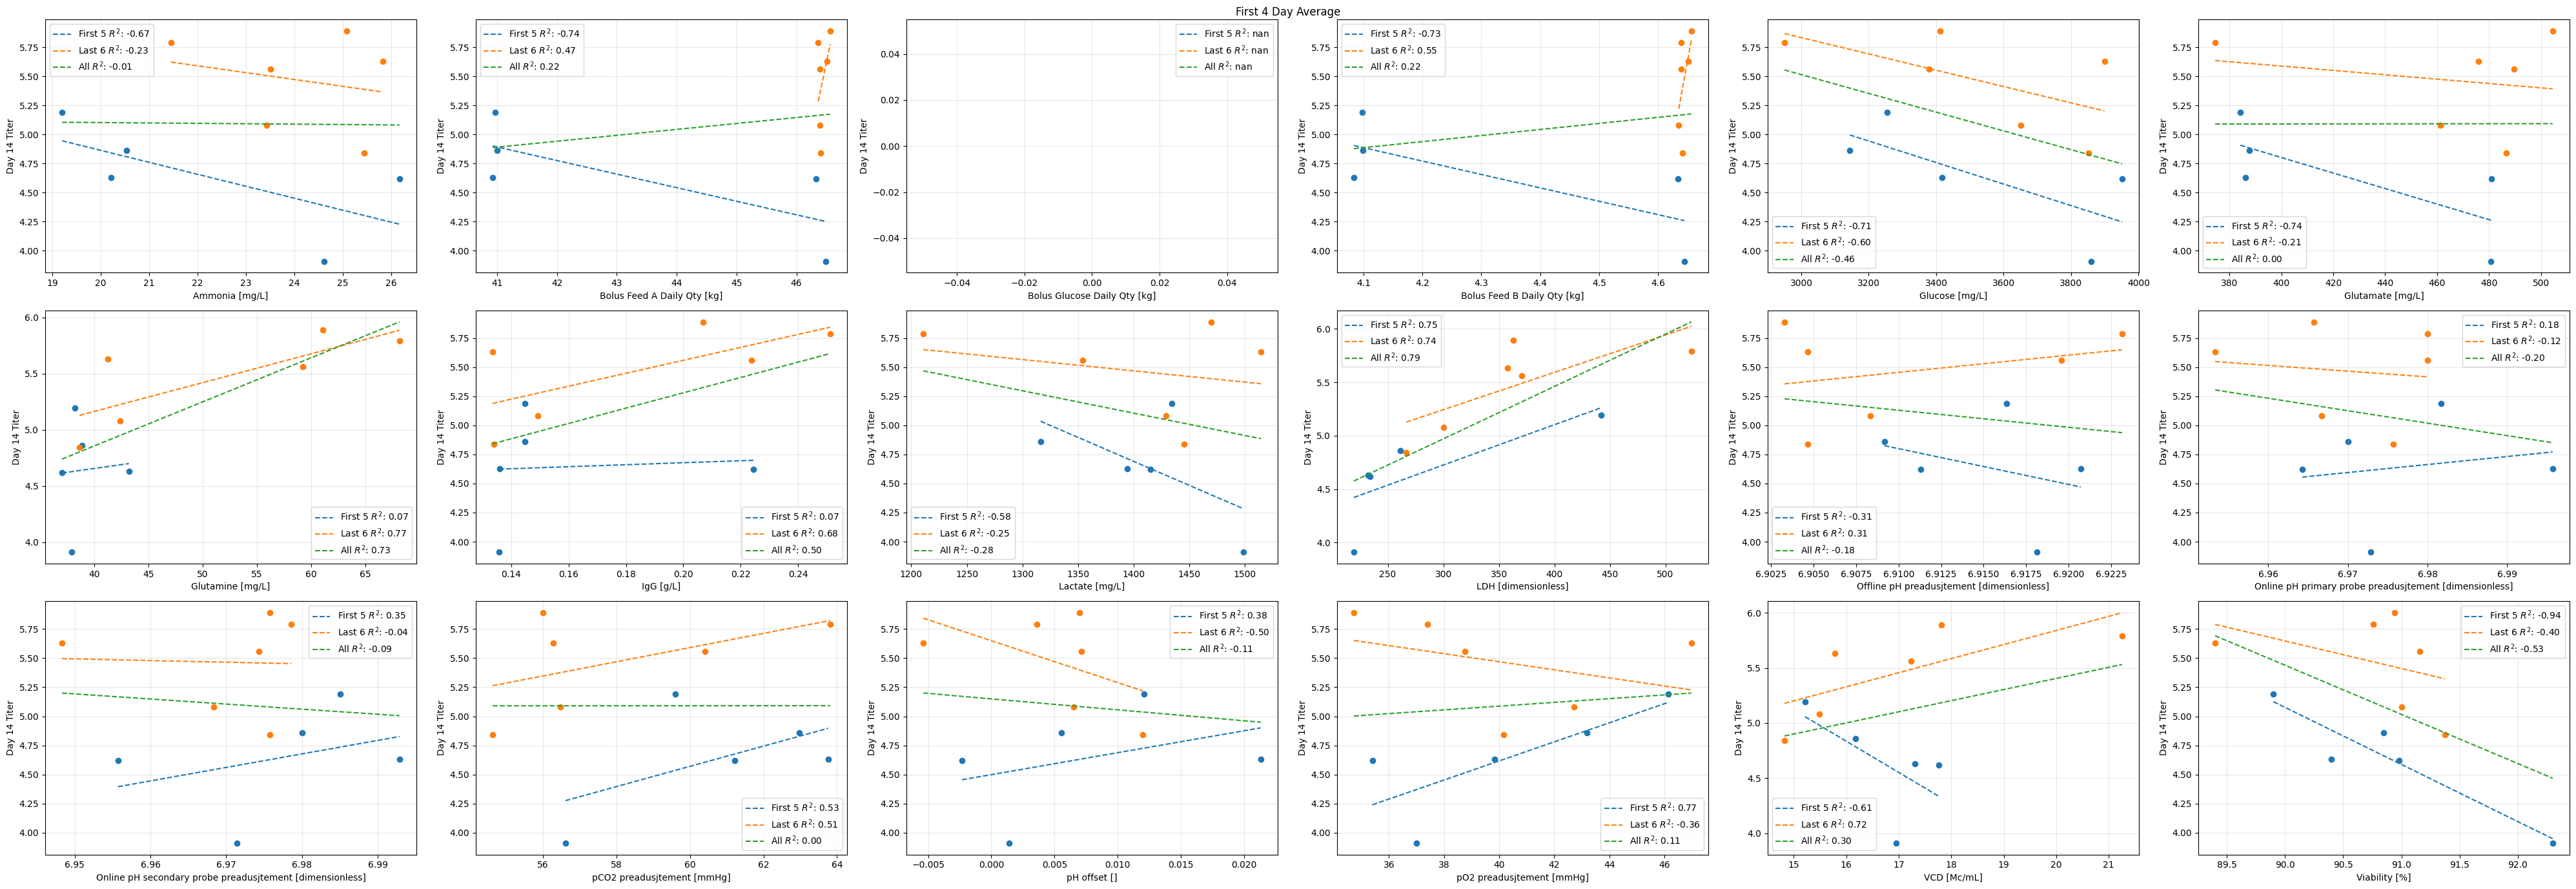

In [37]:
fig, axs = plt.subplots(3, 6, figsize = (40, 14))
label_list = labels[labels.columns[-1]].tolist()

for ax_idx, col in enumerate(four_month.columns[2:]):
    row_idx = ax_idx // 6
    col_idx = ax_idx % 6
    ax = axs[row_idx][col_idx]

    sub_list = four_month[col].tolist()

    ax.scatter(sub_list[:5], label_list[:5])
    ax.scatter(sub_list[5:], label_list[5:])

    min_val, max_val = min(sub_list[:5]), max(sub_list[:5])
    slope, intercept, r, p, se = linregress(sub_list[:5], label_list[:5])
    ax.plot([min_val, max_val], [(slope * i) + intercept for i in [min_val, max_val]], linestyle = "--", label = f"First 5 $R^2$: {r:.2f}")
    
    min_val, max_val = min(sub_list[5:]), max(sub_list[5:])
    slope, intercept, r, p, se = linregress(sub_list[5:], label_list[5:])
    ax.plot([min_val, max_val], [(slope * i) + intercept for i in [min_val, max_val]], linestyle = "--", label = f"Last 6 $R^2$: {r:.2f}")
    
    min_val, max_val = min(sub_list), max(sub_list)
    slope, intercept, r, p, se = linregress(sub_list, label_list)
    ax.plot([min_val, max_val], [(slope * i) + intercept for i in [min_val, max_val]], linestyle = "--", label = f"All $R^2$: {r:.2f}")
    ax.legend()
    ax.set_xlabel(col)
    ax.set_ylabel("Day 14 Titer")
    ax.grid(alpha = 0.3)

fig.suptitle("First 4 Day Average")
fig.tight_layout()
fig.savefig("4DayAverage.png")

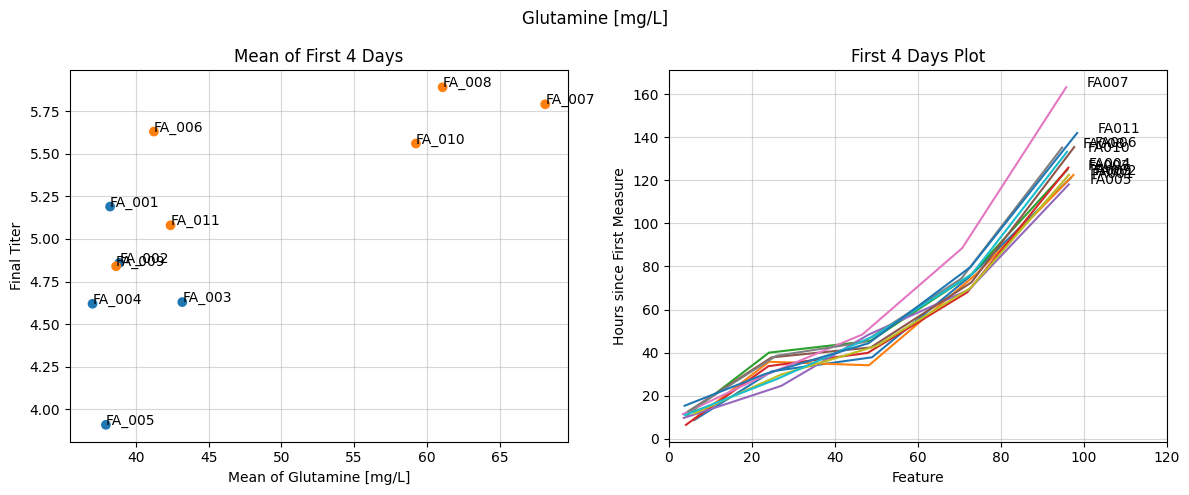

In [72]:
feature = "Glutamine [mg/L]"

fig, axs = plt.subplots(1, 2, figsize = (12, 5))

ax = axs[0]
colors = ["C0"] * 5 + ["C1"] * 6
ax.scatter(four_month[feature], labels[labels.columns[-1]], c = colors)
for idx, (i, j) in enumerate(zip(four_month[feature], labels[labels.columns[-1]])):
    ax.text(i, j, f"FA_{str(idx + 1).zfill(3)}")
ax.grid(alpha = 0.5)
ax.set_title("Mean of First 4 Days")
ax.set_ylabel("Final Titer")
ax.set_xlabel(f"Mean of {feature}")

ax = axs[1]
for run_idx, run in enumerate(sorted(merged_df["Run"].unique())):
    sub_df = merged_df[merged_df["Run"] == run]
    sub_df = sub_df[sub_df["Run Time [h]"] < (100)]
    sub_df = sub_df[~sub_df[feature].isna()]
    ax.plot(sub_df["Run Time [h]"], sub_df[feature])
    ax.text(sub_df["Run Time [h]"].max() + 5, sub_df[feature].iloc[-1], run.split("_")[0])
ax.set_xlim(0, 120)
ax.grid(alpha = 0.5)
ax.set_title("First 4 Days Plot")
ax.set_ylabel("Hours since First Measure")
ax.set_xlabel("Feature")

fig.suptitle(feature)
fig.tight_layout()

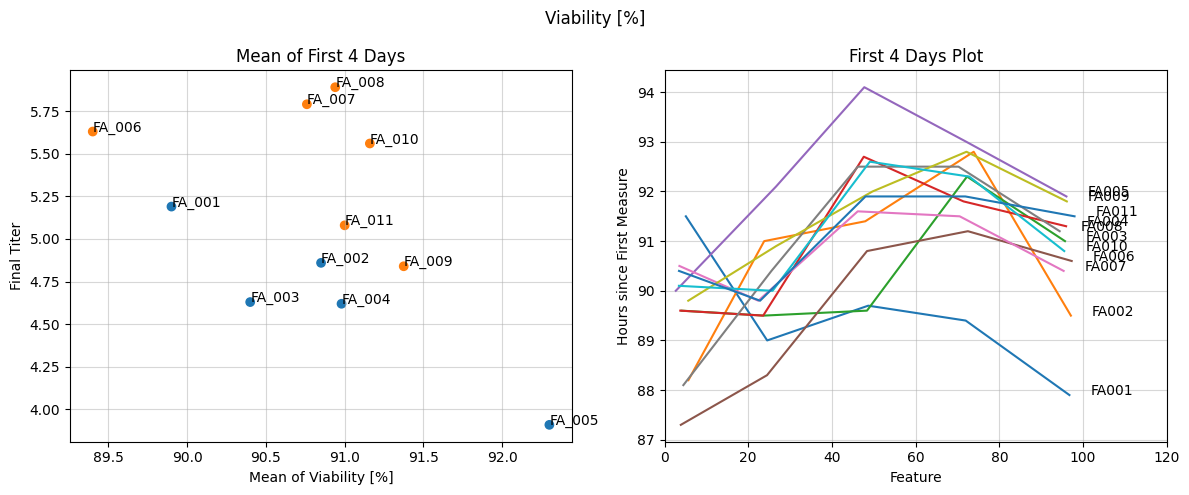

In [75]:
feature = "Viability [%]"

fig, axs = plt.subplots(1, 2, figsize = (12, 5))

ax = axs[0]
colors = ["C0"] * 5 + ["C1"] * 6
ax.scatter(four_month[feature], labels[labels.columns[-1]], c = colors)
for idx, (i, j) in enumerate(zip(four_month[feature], labels[labels.columns[-1]])):
    ax.text(i, j, f"FA_{str(idx + 1).zfill(3)}")
ax.grid(alpha = 0.5)
ax.set_title("Mean of First 4 Days")
ax.set_ylabel("Final Titer")
ax.set_xlabel(f"Mean of {feature}")

ax = axs[1]
for run_idx, run in enumerate(sorted(merged_df["Run"].unique())):
    sub_df = merged_df[merged_df["Run"] == run]
    sub_df = sub_df[sub_df["Run Time [h]"] < (100)]
    sub_df = sub_df[~sub_df[feature].isna()]
    ax.plot(sub_df["Run Time [h]"], sub_df[feature])
    ax.text(sub_df["Run Time [h]"].max() + 5, sub_df[feature].iloc[-1], run.split("_")[0])
ax.set_xlim(0, 120)
ax.grid(alpha = 0.5)
ax.set_title("First 4 Days Plot")
ax.set_ylabel("Hours since First Measure")
ax.set_xlabel("Feature")

fig.suptitle(feature)
fig.tight_layout()

In [23]:
labels

,Unnamed: 0,STR2K_D14_4_1_PA_HPLC_Concentration
0,FA001,5.19
1,FA002,4.86
2,FA003,4.63
3,FA004,4.62
4,FA005,3.91
5,FA006,5.63
6,FA007,5.79
7,FA008,5.89
8,FA009,4.84
9,FA010,5.56


In [104]:
def extract_features(times, series):
    try:
        data = {
            "min": min(series),
            "max": max(series),
            "first": series.tolist()[0],
            "last": series.tolist()[-1],
            "mean": np.mean(series).item(),
            "slope": linregress(times, series).slope.item()
        }
    except:
        data = {
            "min": np.nan,
            "max": np.nan,
            "mean": np.nan,
            "slope": np.nan
        }
        

    return data

In [100]:
ts_stat = []

time_col = "Process Time [h]"

for run in sorted(df["Run"].unique()):
    sub_df = df[df["Run"] == run]
    run_data = {"Run" : run.split("_")[0]}
    for col in df.columns[2:]:
        sub_sub_df = sub_df[[time_col, col]].copy()
        sub_sub_df[time_col] = sub_sub_df[time_col] - sub_sub_df[time_col].min()
        sub_sub_df = sub_sub_df[~sub_sub_df[col].isna()]
        sub_sub_df = sub_sub_df[sub_sub_df[time_col] < 24 * 4]
        feats = extract_features(sub_sub_df[time_col], sub_sub_df[col])
        for key, val in feats.items():
            run_data[f"{col}_{key}"] = val
    ts_stat.append(run_data)
ts_stat = pd.DataFrame(ts_stat)

In [101]:
correlation_df = []
for col in ts_stat.columns[1:]:
    corr = np.corrcoef(ts_stat[col].astype(float).tolist(), labels[labels.columns[-1]].tolist())[0, 1]
    correlation_df.append([col, corr, abs(corr)])
correlation_df = pd.DataFrame(correlation_df, columns = ["Feature Stat", "Correlation", "Absolute Correlation"])
correlation_df = correlation_df.sort_values(by = "Absolute Correlation", ascending = False)
correlation_df["Correlation Order"] = [i + 1 for i in range(len(correlation_df))]
correlation_df.insert(1, "Feature Name", correlation_df["Feature Stat"].apply(lambda x: "_".join(x.split("_")[:-1])))
correlation_df

,Feature Stat,Feature Name,Correlation,Absolute Correlation,Correlation Order
55,LDH [dimensionless]_last,LDH [dimensionless],0.820946,0.820946,1
53,LDH [dimensionless]_max,LDH [dimensionless],0.797723,0.797723,2
56,LDH [dimensionless]_mean,LDH [dimensionless],0.791614,0.791614,3
38,Glutamine [mg/L]_mean,Glutamine [mg/L],0.731530,0.731530,4
54,LDH [dimensionless]_first,LDH [dimensionless],0.725606,0.725606,5
...,...,...,...,...,...
80,pCO2 preadusjtement [mmHg]_mean,pCO2 preadusjtement [mmHg],0.000777,0.000777,102
12,Bolus Glucose Daily Qty [kg]_min,Bolus Glucose Daily Qty [kg],NaN,NaN,103
13,Bolus Glucose Daily Qty [kg]_max,Bolus Glucose Daily Qty [kg],NaN,NaN,104
14,Bolus Glucose Daily Qty [kg]_mean,Bolus Glucose Daily Qty [kg],NaN,NaN,105


In [102]:
correlation_df.drop_duplicates("Feature Name", keep = "first")

,Feature Stat,Feature Name,Correlation,Absolute Correlation,Correlation Order
55,LDH [dimensionless]_last,LDH [dimensionless],0.820946,0.820946,1
38,Glutamine [mg/L]_mean,Glutamine [mg/L],0.731530,0.731530,4
51,Lactate [mg/L]_slope,Lactate [mg/L],-0.721228,0.721228,6
101,Viability [%]_max,Viability [%],-0.706758,0.706758,9
43,IgG [g/L]_last,IgG [g/L],0.697450,0.697450,10
5,Ammonia [mg/L]_slope,Ammonia [mg/L],-0.624374,0.624374,16
33,Glutamate [mg/L]_slope,Glutamate [mg/L],-0.620231,0.620231,17
25,Glucose [mg/L]_last,Glucose [mg/L],-0.576714,0.576714,18
21,Bolus Feed B Daily Qty [kg]_slope,Bolus Feed B Daily Qty [kg],-0.559871,0.559871,21
90,pO2 preadusjtement [mmHg]_first,pO2 preadusjtement [mmHg],0.439041,0.439041,29


In [97]:
correlation_df.drop_duplicates("Feature Name", keep = "first")

,Feature Stat,Feature Name,Correlation,Absolute Correlation,Correlation Order
55,LDH [dimensionless]_last,LDH [dimensionless],0.820946,0.820946,1
38,Glutamine [mg/L]_mean,Glutamine [mg/L],0.731530,0.731530,4
51,Lactate [mg/L]_slope,Lactate [mg/L],-0.721228,0.721228,6
101,Viability [%]_max,Viability [%],-0.706758,0.706758,9
43,IgG [g/L]_last,IgG [g/L],0.697450,0.697450,10
5,Ammonia [mg/L]_slope,Ammonia [mg/L],-0.624374,0.624374,16
33,Glutamate [mg/L]_slope,Glutamate [mg/L],-0.620231,0.620231,17
25,Glucose [mg/L]_last,Glucose [mg/L],-0.576714,0.576714,18
21,Bolus Feed B Daily Qty [kg]_slope,Bolus Feed B Daily Qty [kg],-0.559871,0.559871,21
90,pO2 preadusjtement [mmHg]_first,pO2 preadusjtement [mmHg],0.439041,0.439041,29
